In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


#### This script is used to diagnose the actual structure of the TripAdvisor CSV datasets before performing data cleaning, merging, or modeling. It first lists all CSV files in the current directory to verify that the expected files exist, then checks each target file and reads only the first five rows to quickly inspect the data structure without loading the full dataset. The script prints the number of columns, column names, data types, and non-null counts, and automatically identifies potential long text fields as well as possible ID columns based on their names. Finally, it summarizes the key field names (such as review text, rating, and place ID) to ensure that later analysis does not fail due to incorrect column references or unexpected data formats. Essentially, it functions as a structural “sanity check” tool before deeper data analysis.

In [4]:
import pandas as pd
import os

print("TripAdvisor Data Diagnosis Tool")

print("\n1. Available CSV files:")
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
for f in csv_files:
    print(f"   - {f}")


files_to_check = [
    'reviews83325.csv',
    'Tripadvisor.csv',
    'AttractionSubCategorie.csv',
    'AttractionSubType.csv',
    'cuisine.csv',
    'dietary_restrictions.csv',
    'restaurantType.csv'
]

for filename in files_to_check:
    if not os.path.exists(filename):
        print(f"\n {filename} not found!")
        continue
    
    print(f"File: {filename}")
    
    try:
        df = pd.read_csv(filename, nrows=5)
        
        print(f"\nShape: {df.shape[0]} rows (showing first 5), {df.shape[1]} columns")
        print(f"\nColumn names and types:")
        for col in df.columns:
            dtype = df[col].dtype
            non_null = df[col].notna().sum()
            print(f"   - {col:30s} | {str(dtype):15s} | {non_null}/5 non-null")
        
        print(f"\nFirst 3 rows:")
        print(df.head(3).to_string())
        
        print(f"\nText columns detected:")
        text_cols = []
        for col in df.columns:
            if df[col].dtype == 'object':
                avg_len = df[col].fillna('').astype(str).str.len().mean()
                if avg_len > 50:
                    text_cols.append(col)
                    print(f" {col} (avg length: {avg_len:.0f} chars)")
        
        if not text_cols:
            print(" No text columns found (all columns too short)")
        
        print(f"\nPotential ID columns:")
        id_cols = []
        for col in df.columns:
            if 'id' in col.lower():
                unique_count = df[col].nunique()
                id_cols.append(col)
                print(f" {col} ({unique_count} unique values)")
        
        if not id_cols:
            print(" No ID columns found")
            
    except Exception as e:
        print(f" Error reading file: {e}")

print("SUMMARY")

print("""
Based on the diagnosis, the correct column names are:

FOR REVIEWS (reviews83325.csv):
   - Review text: 'review'
   - Place ID: 'idplace'
   - Rating: 'note'
   - Language: 'langue'

FOR METADATA (Tripadvisor.csv):
   - Place ID: 'id'
   - Type: 'typeR' (H/R/A/AP)
   - Attraction: 'activiteSubCategorie', 'activiteSubType'
   - Restaurant: 'restaurantType', 'cuisine'
   - Hotel: 'priceRange'
""")

TripAdvisor Data Diagnosis Tool

1. Available CSV files:
   - reviews83325.csv
   - dietary_restrictions.csv
   - documents_by_place_tfidf.csv
   - documents_by_place.csv
   - AttractionSubCategorie.csv
   - Tripadvisor.csv
   - restaurantType.csv
   - AttractionSubType.csv
   - reviews_preprocessed.csv
   - cuisine.csv
File: reviews83325.csv

Shape: 5 rows (showing first 5), 21 columns

Column names and types:
   - id                             | int64           | 5/5 non-null
   - idplace                        | int64           | 5/5 non-null
   - titre                          | str             | 5/5 non-null
   - idauteur                       | str             | 5/5 non-null
   - review                         | str             | 5/5 non-null
   - note                           | int64           | 5/5 non-null
   - date_review                    | str             | 5/5 non-null
   - date_visit                     | str             | 5/5 non-null
   - langue                      

#### It performs an EDA (exploratory data analysis): loads all CSVs, prints structure/missing/types for reviews and places, inspects metadata tables, computes key distributions (reviews per place, text length, language, place type), generates 4 plots saved as data_exploration.png, and prints summary findings.

Loading all data files...


/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_97299/975541879.py:13: DtypeWarning: Columns (0: owner_langue, 1: owner_date_review, 2: owner_connection, 3: owner_responder, 4: owner_response, 5: owner_title) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv('reviews83325.csv')


REVIEWS DATA (reviews83325.csv)
Shape: (340385, 21)
Columns: ['id', 'idplace', 'titre', 'idauteur', 'review', 'note', 'date_review', 'date_visit', 'langue', 'published_platform', 'typeReview', 'subratings', 'machine_translated', 'machine_translatable', 'owner_id', 'owner_langue', 'owner_date_review', 'owner_connection', 'owner_responder', 'owner_response', 'owner_title']

First 3 rows:
          id  idplace                titre                          idauteur  \
0  771569620   188467             February  F645CC9429E8A40EB1F5A487780EC683   
1  769814072   188467    Nice green square  AFFB511F21DF819776CB2F8013034382   
2  758953508   188467  A Treasure in Paris  9262311F3378F8CC4709DD4D92380278   

                                                                                                review  \
0  Personally I think it is the most beautiful square of Paris. Well maintained and the area around...   
1  We walked through this lovely park but did not stay long. It is a square, l

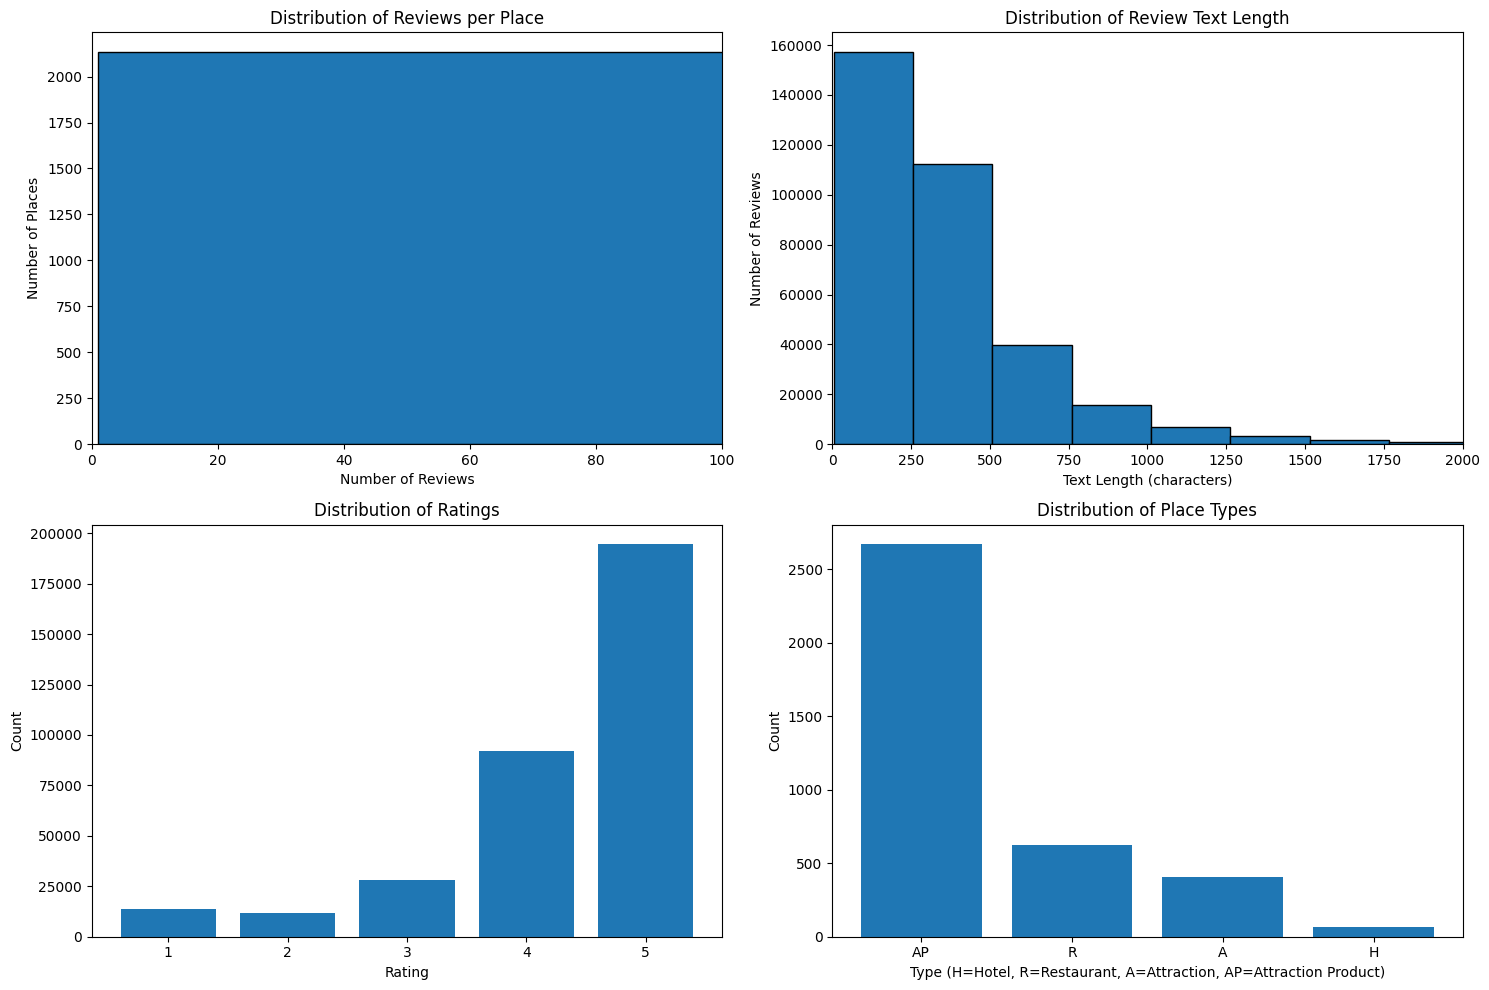

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Display options (only affect printing, not the data itself)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("Loading all data files...")

reviews_df = pd.read_csv('reviews83325.csv')
tripadvisor_df = pd.read_csv('Tripadvisor.csv')

attraction_subcategory_df = pd.read_csv('AttractionSubCategorie.csv')
attraction_subtype_df = pd.read_csv('AttractionSubType.csv')
cuisine_df = pd.read_csv('cuisine.csv')
dietary_restrictions_df = pd.read_csv('dietary_restrictions.csv')
restaurant_type_df = pd.read_csv('restaurantType.csv')

#Inspect reviews data (core)
print("REVIEWS DATA (reviews83325.csv)")
print(f"Shape: {reviews_df.shape}")
print(f"Columns: {list(reviews_df.columns)}\n")
print("First 3 rows:")
print(reviews_df.head(3))
print("Data types:")
print(reviews_df.dtypes)
print("Missing values:")
print(reviews_df.isnull().sum())
print("Basic statistics:")
print(reviews_df.describe())
print("\n")

#Inspect place metadata table
print("TRIPADVISOR DATA (Tripadvisor.csv)")
print(f"Shape: {tripadvisor_df.shape}")
print(f"Columns: {list(tripadvisor_df.columns)}\n")
print("First 3 rows:")
print(tripadvisor_df.head(3))
print("Missing values:")
print(tripadvisor_df.isnull().sum())
print("\n")

#other files
print("METADATA FILES")
metadata_files = {
    'AttractionSubCategorie': attraction_subcategory_df,
    'AttractionSubType': attraction_subtype_df,
    'Cuisine': cuisine_df,
    'Dietary Restrictions': dietary_restrictions_df,
    'Restaurant Type': restaurant_type_df
}

#loop through each metadata df and print overview
for name, df in metadata_files.items():
    print(f"\n{name}:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Sample:\n{df.head(2)}")

print("DATA RELATIONSHIPS")

#Reviews per place: how many reviews each place has
reviews_per_place = reviews_df.groupby('idplace').size()
print(f"\nReviews per place statistics:")
print(f"Total unique places: {reviews_per_place.shape[0]}")
print(f"Min reviews: {reviews_per_place.min()}")
print(f"Max reviews: {reviews_per_place.max()}")
print(f"Mean reviews: {reviews_per_place.mean():.2f}")
print(f"Median reviews: {reviews_per_place.median():.2f}")

#Review text length (characters)
reviews_df['text_length'] = reviews_df['review'].fillna('').str.len()
print(f"\nReview text length statistics:")
print(f"Min length: {reviews_df['text_length'].min()}")
print(f"Max length: {reviews_df['text_length'].max()}")
print(f"Mean length: {reviews_df['text_length'].mean():.2f}")
print(f"Median length: {reviews_df['text_length'].median():.2f}")

print(f"\nLanguage distribution:")
lang_counts = reviews_df['langue'].value_counts()
print(lang_counts.head(10))
print(f"\nEnglish reviews: {lang_counts.get('en', 0)} ({lang_counts.get('en', 0)/len(reviews_df)*100:.2f}%)")

print(f"\nPlace type distribution (typeR):")
type_counts = tripadvisor_df['typeR'].value_counts()
print(type_counts)

"""

print("Saving exploration results...")

with open('data_exploration_report.txt', 'w', encoding='utf-8') as f:
    f.write("TripAdvisor Dataset Exploration Report\n")
    
    f.write("1. REVIEWS DATA\n")
    f.write(f"Shape: {reviews_df.shape}\n")
    f.write(f"Columns: {list(reviews_df.columns)}\n")
    f.write(f"Missing values:\n{reviews_df.isnull().sum()}\n\n")
    
    f.write("2. REVIEWS PER PLACE\n")
    f.write(f"Unique places: {reviews_per_place.shape[0]}\n")
    f.write(f"Mean reviews: {reviews_per_place.mean():.2f}\n")
    f.write(f"Median reviews: {reviews_per_place.median():.2f}\n\n")
    
    f.write("3. LANGUAGE DISTRIBUTION\n")
    f.write(f"{lang_counts.head(10)}\n\n")
    
    f.write("4. PLACE TYPES\n")
    f.write(f"{type_counts}\n\n")
    
    f.write("5. TRIPADVISOR DATA\n")
    f.write(f"Shape: {tripadvisor_df.shape}\n")
    f.write(f"Columns: {list(tripadvisor_df.columns)}\n\n")

print("Report saved to 'data_exploration_report.txt'"）
"""

print("\nCreating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#Plot 1: distribution of reviews per place (histogram)
axes[0, 0].hist(reviews_per_place, bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Reviews per Place')
axes[0, 0].set_xlabel('Number of Reviews')
axes[0, 0].set_ylabel('Number of Places')
axes[0, 0].set_xlim(0, min(100, reviews_per_place.max()))

#Plot 2: distribution of review text length (histogram)
axes[0, 1].hist(reviews_df['text_length'], bins=50, edgecolor='black')
axes[0, 1].set_title('Distribution of Review Text Length')
axes[0, 1].set_xlabel('Text Length (characters)')
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_xlim(0, min(2000, reviews_df['text_length'].max()))

#Plot 3: rating distribution (bar chart)
rating_counts = reviews_df['note'].value_counts().sort_index()
axes[1, 0].bar(rating_counts.index, rating_counts.values)
axes[1, 0].set_title('Distribution of Ratings')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticks(rating_counts.index)

#Plot 4: place type distribution (bar chart)
axes[1, 1].bar(type_counts.index, type_counts.values)
axes[1, 1].set_title('Distribution of Place Types')
axes[1, 1].set_xlabel('Type (H=Hotel, R=Restaurant, A=Attraction, AP=Attraction Product)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
print("Visualizations saved to 'data_exploration.png'")

print("\nKey findings:")
print(f"Total reviews: {len(reviews_df):,}")
print(f"Unique places: {reviews_per_place.shape[0]:,}")
print(f"English reviews: {lang_counts.get('en', 0):,} ({lang_counts.get('en', 0)/len(reviews_df)*100:.2f}%)")
print(f"Average reviews per place: {reviews_per_place.mean():.2f}")
print(f"Average review length: {reviews_df['text_length'].mean():.0f} characters")

#### This TextPreprocessor class implements a complete text preprocessing pipeline for English and French reviews. It first builds a multilingual stopword set and initializes a WordNet lemmatizer. The preprocessing workflow includes cleaning the raw text (lowercasing, removing URLs, HTML tags, emails, numbers, punctuation, and extra spaces), tokenizing the text into words, removing stopwords and very short tokens, and finally lemmatizing each word to its base form. The preprocess method integrates all these steps into a single function and can return either a cleaned string or a list of processed tokens, making it flexible for downstream tasks such as frequency analysis, TF-IDF, topic modeling, or machine learning.

In [7]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
import nltk

print("Downloading NLTK data...")
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('punkt', quiet=True)
    print("NLTK data downloaded\n")
except:
    print("NLTK download may have issues, continuing...\n")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


class TextPreprocessor:
    #Text preprocessing class (supports English and French)
    def __init__(self, languages=['english', 'french']):
        #Build a combined stopword set for multiple languages
        self.stop_words = set()
        for lang in languages:
            try:
                #Load stopwords for each language and merge into one set
                self.stop_words.update(stopwords.words(lang))
            except:
                #Fallback if a language stopword list is not available
                print(f"Stopwords for {lang} not available")
        
        #Initialize lemmatizer (reduces words to base form)
        self.lemmatizer = WordNetLemmatizer()
        
    def clean_text(self, text):
        #Return empty string for NaN or empty input
        if pd.isna(text) or text == '':
            return ''
        #Lowercase normalization
        text = str(text).lower()
        #Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        #Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        #Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        #Remove digits/numbers
        text = re.sub(r'\d+', '', text)
        #Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        #Collapse multiple spaces and trim
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    def tokenize(self, text):
        #Tokenize text into words (returns list of tokens)
        if text == '':
            return []
        try:
            #Use NLTK tokenizer (handles punctuation/spacing better)
            return word_tokenize(text)
        except:
            #Fallback: simple whitespace split if tokenizer fails
            return text.split()
    
    def remove_stopwords(self, tokens):
        #Remove stopwords and very short tokens
        return [word for word in tokens if word not in self.stop_words and len(word) > 2]
    
    def lemmatize(self, tokens):
        #Lemmatize tokens to their base form
        return [self.lemmatizer.lemmatize(word) for word in tokens]
    
    def preprocess(self, text, return_tokens=False):
        #Full pipeline: clean - tokenize -remove stopwords -lemmatize
        text = self.clean_text(text)
        if text == '':
            return [] if return_tokens else ''
        #Tokenize
        tokens = self.tokenize(text)
        #Stopword removal
        tokens = self.remove_stopwords(tokens)
        #Lemmatization
        tokens = self.lemmatize(tokens)
        #Return tokens or a single space-joined string
        if return_tokens:
            return tokens
        else:
            return ' '.join(tokens)

NLTK data downloaded



In [8]:
def filter_english_reviews(reviews_df, language_column='langue'):
    print("Filtering English Reviews")
    
    original_count = len(reviews_df)
    english_df = reviews_df[reviews_df[language_column] == 'en'].copy()
    
    print(f"\nOriginal reviews: {original_count:,}")
    print(f"English reviews: {len(english_df):,}")
    print(f"Percentage: {len(english_df)/original_count*100:.2f}%")
    
    return english_df

In [10]:
def balance_reviews_per_place(reviews_df, id_column='idplace', max_reviews=50):
    print(f"Balancing Reviews (max {max_reviews} per place)")
    reviews_per_place = reviews_df.groupby(id_column).size()
    
    print(f"\nBefore balancing:")
    print(f"Mean reviews per place: {reviews_per_place.mean():.2f}")
    print(f"Median: {reviews_per_place.median():.2f}")
    print(f"Max: {reviews_per_place.max()}")
    
    #Resrict the comments in each places
    balanced_df = reviews_df.groupby(id_column).head(max_reviews).reset_index(drop=True)
    
    reviews_per_place_balanced = balanced_df.groupby(id_column).size()
    
    print(f"\nAfter balancing:")
    print(f"Mean reviews per place: {reviews_per_place_balanced.mean():.2f}")
    print(f"Median: {reviews_per_place_balanced.median():.2f}")
    print(f"Max: {reviews_per_place_balanced.max()}")
    print(f"Total reviews: {len(balanced_df):,}")
    
    return balanced_df

#### This function preprocess_reviews_data performs a structured preprocessing pipeline on the reviews dataset. It first creates a copy of the original dataframe and removes rows with missing review text or place IDs. It then analyzes the distribution of reviews per place to understand dataset balance. Next, it applies the TextPreprocessor to clean and normalize all review texts in batches, improving efficiency for large datasets. After preprocessing, it removes empty cleaned texts and calculates word count statistics such as average, minimum, maximum, and median words per review. Overall, the function prepares the dataset for downstream NLP tasks such as feature extraction, sentiment analysis, or machine learning.

In [11]:
def preprocess_reviews_data(reviews_df, text_column='review', id_column='idplace'):
    print("Starting data preprocessing")
    
    df = reviews_df.copy()
    
    print(f"\nOriginal dataset:")
    print(f"Total rows:{len(df):,}")
    print(f"Using text column:'{text_column}'")
    print(f"Using ID column:'{id_column}'")
    
    #1.Check and handle missing values
    print(f"\n1.Handling missing values...")
    print(f"Missing values in '{text_column}':{df[text_column].isna().sum()}")
    df = df.dropna(subset=[text_column, id_column])
    print(f"Dropped rows with missing text or ID")
    print(f"Remaining rows:{len(df):,}")
    
    #2.Analyze review distribution
    print(f"\n2.Analyzing review distribution...")
    reviews_per_place = df.groupby(id_column).size()
    print(f"Unique places:{len(reviews_per_place):,}")
    print(f"Min reviews per place:{reviews_per_place.min()}")
    print(f"Max reviews per place:{reviews_per_place.max()}")
    print(f"Mean reviews per place:{reviews_per_place.mean():.2f}")
    print(f"Median reviews per place:{reviews_per_place.median():.2f}")
    
    #3.Text preprocessing
    print(f"\n3.Preprocessing text...")
    preprocessor = TextPreprocessor(languages=['english', 'french'])
    
    #Show an example
    print(f"\nExample BEFORE preprocessing:")
    sample_text = df[text_column].iloc[0]
    print(f"'{sample_text[:200]}'")
    
    #Process all texts in batches (to show progress)
    print(f"\nProcessing {len(df):,} reviews...")
    
    batch_size = 10000
    cleaned_texts = []
    
    for i in range(0, len(df), batch_size):
        batch = df[text_column].iloc[i:i+batch_size]
        batch_cleaned = batch.apply(preprocessor.preprocess)
        cleaned_texts.extend(batch_cleaned.tolist())
        print(f"Processed {min(i+batch_size, len(df)):,}/{len(df):,} reviews")
    
    df['cleaned_text'] = cleaned_texts
    
    #Show an example after processing
    print(f"\n Example AFTER preprocessing:")
    print(f"'{df['cleaned_text'].iloc[0][:200]}...'")
    
    #4.Remove empty texts
    print(f"\n4.Removing empty texts...")
    original_len = len(df)
    df = df[df['cleaned_text'].str.len() > 0]
    removed = original_len - len(df)
    print(f"Removed {removed:,} empty reviews ({removed/original_len*100:.2f}%)")
    print(f"Remaining rows:{len(df):,}")
    
    #5.Statistics after preprocessing
    print(f"\n5.Statistics after preprocessing:")
    df['word_count'] = df['cleaned_text'].str.split().str.len()
    print(f"Average words per review:{df['word_count'].mean():.2f}")
    print(f"Min words:{df['word_count'].min()}")
    print(f"Max words:{df['word_count'].max()}")
    print(f"Median words:{df['word_count'].median():.2f}")
    
    return df

#### The two functions complete the final stages of the preprocessing pipeline. The aggregate_reviews_by_place function groups all cleaned reviews by place ID and combines them into a single document per place, while also calculating statistics such as document length and the number of reviews per place. This transforms individual reviews into place-level textual representations, which are useful for topic modeling, clustering, or place-level sentiment analysis. The save_preprocessed_data function then saves the processed review dataset, the aggregated place-level documents, and a summary report containing key statistics. Together, these functions structure, summarize, and export the cleaned data, making it ready for downstream NLP analysis or machine learning tasks.

In [12]:
def aggregate_reviews_by_place(processed_df, id_column='idplace', text_column='cleaned_text'):
    #Combine all reviews for each place into one document
    
    print("Aggregating reviews by place...")
    print(f"\nCombining all reviews for each place...")
    
    #Aggregate text and compute statistics
    aggregated = processed_df.groupby(id_column).agg({
        text_column: lambda x: ' '.join(x),#Concatenate all review texts
        'id': 'count',#Number of reviews
    }).reset_index()
    
    #Rename columns
    aggregated.columns = [id_column, 'document', 'review_count']
    
    #Statistics
    print(f"\nAggregation statistics:")
    print(f"Total unique places:{len(aggregated):,}")
    
    aggregated['doc_length'] = aggregated['document'].str.split().str.len()
    print(f"\n   Document length (in words):")
    print(f"Mean:{aggregated['doc_length'].mean():.2f}")
    print(f"Min:{aggregated['doc_length'].min()}")
    print(f"Max:{aggregated['doc_length'].max()}")
    print(f"Median:{aggregated['doc_length'].median():.2f}")
    
    print(f"\n   Reviews per place:")
    print(f"Mean:{aggregated['review_count'].mean():.2f}")
    print(f"Min:{aggregated['review_count'].min()}")
    print(f"Max:{aggregated['review_count'].max()}")
    print(f"Median:{aggregated['review_count'].median():.2f}")
    
    return aggregated

In [13]:
def save_preprocessed_data(processed_reviews_df, aggregated_df):
    #Save preprocessed data and summary files
    print("Saving preprocessed data...")
    
    #Save processed reviews
    print("\n1.Saving processed reviews...")
    processed_reviews_df.to_csv('reviews_preprocessed.csv', index=False)
    print("Saved'reviews_preprocessed.csv'")
    
    #Save aggregated documents
    print("\n2.Saving aggregated documents...")
    aggregated_df.to_csv('documents_by_place.csv', index=False)
    print("Saved'documents_by_place.csv'")
    
    #Save summary statistics
    print("\n3.Saving summary statistics...")
    with open('preprocessing_summary.txt', 'w', encoding='utf-8') as f:
        f.write("TripAdvisor Data Preprocessing Summary\n")
        f.write("-"*60 + "\n\n")
        
        f.write("1.PROCESSED REVIEWS\n")
        f.write(f"Total reviews processed:{len(processed_reviews_df):,}\n")
        f.write(f"Average words per review:{processed_reviews_df['word_count'].mean():.2f}\n")
        f.write(f"Min words:{processed_reviews_df['word_count'].min()}\n")
        f.write(f"Max words:{processed_reviews_df['word_count'].max()}\n\n")
        
        f.write("2.AGGREGATED DOCUMENTS\n")
        f.write(f"Total unique places:{len(aggregated_df):,}\n")
        f.write(f"Average document length:{aggregated_df['doc_length'].mean():.2f}words\n")
        f.write(f"Average reviews per place:{aggregated_df['review_count'].mean():.2f}\n")
        f.write(f"Min reviews per place:{aggregated_df['review_count'].min()}\n")
        f.write(f"Max reviews per place:{aggregated_df['review_count'].max()}\n\n")
        
        f.write("3.OUTPUT FILES\n")
        f.write("reviews_preprocessed.csv:All reviews with cleaned text\n")
        f.write("documents_by_place.csv:Aggregated documents(one per place)\n")
        f.write("preprocessing_summary.txt:This file\n")
    
    print("Saved'preprocessing_summary.txt'")

#### This __main__ block runs the entire TripAdvisor preprocessing pipeline end-to-end. It loads the raw reviews file, optionally filters the dataset to English-only reviews, and optionally balances the number of reviews kept per place to reduce bias from places with extremely many reviews. It then preprocesses the review text (cleaning and normalizing), aggregates all cleaned reviews into one document per place, and finally saves the processed reviews, the aggregated place-level documents, and a summary statistics report. In short, it provides a configurable, step-by-step workflow that turns raw review data into clean, exportable outputs ready for downstream NLP or machine learning tasks.

In [14]:
if __name__ == "__main__":
    print("TripAdvisor Data Preprocessing Pipeline")
    
    #Configuration options
    USE_ENGLISH_ONLY = False #Set True to keep only English reviews
    BALANCE_REVIEWS = False #Set True to balance the number of reviews per place
    MAX_REVIEWS_PER_PLACE = 50 #If BALANCE_REVIEWS=True, keep at most this many reviews per place
    
    #Load data
    print("\nStep 1: Loading data...")
    reviews_df = pd.read_csv('reviews83325.csv')
    print(f"Loaded {len(reviews_df):,} reviews")
    
    #Optional: filter English reviews
    if USE_ENGLISH_ONLY:
        print("\nStep 2: Filtering English reviews...")
        reviews_df = filter_english_reviews(reviews_df, language_column='langue')
    else:
        print("\nStep 2: Using all languages (English + French + others)")
    
    #Optional: balance reviews per place
    if BALANCE_REVIEWS:
        reviews_df = balance_reviews_per_place(
            reviews_df,
            id_column='idplace',
            max_reviews=MAX_REVIEWS_PER_PLACE
        )
    
    #Preprocess reviews
    print(f"\nStep 3: Preprocessing reviews...")
    processed_reviews_df = preprocess_reviews_data(
        reviews_df,
        text_column='review',
        id_column='idplace'
    )
    
    #Aggregate reviews by place
    print(f"\nStep 4: Aggregating reviews by place...")
    aggregated_df = aggregate_reviews_by_place(
        processed_reviews_df,
        id_column='idplace',
        text_column='cleaned_text'
    )
    
    #Save outputs
    print(f"\nStep 5: Saving results...")
    save_preprocessed_data(processed_reviews_df, aggregated_df)
    
    print("Preprocessing completed successfully!")
    print("\nOutput files generated:")
    print("reviews_preprocessed.csv(all reviews, cleaned)")
    print("documents_by_place.csv(aggregated by place)-MAIN OUTPUT")
    print("preprocessing_summary.txt(statistics)")

TripAdvisor Data Preprocessing Pipeline

Step 1: Loading data...


/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_97299/2588580456.py:11: DtypeWarning: Columns (0: owner_langue, 1: owner_date_review, 2: owner_connection, 3: owner_responder, 4: owner_response, 5: owner_title) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv('reviews83325.csv')


Loaded 340,385 reviews

Step 2: Using all languages (English + French + others)

Step 3: Preprocessing reviews...
Starting data preprocessing

Original dataset:
Total rows:340,385
Using text column:'review'
Using ID column:'idplace'

1.Handling missing values...
Missing values in 'review':0
Dropped rows with missing text or ID
Remaining rows:340,385

2.Analyzing review distribution...
Unique places:2,161
Min reviews per place:1
Max reviews per place:71257
Mean reviews per place:157.51
Median reviews per place:10.00

3.Preprocessing text...

Example BEFORE preprocessing:
'Personally I think it is the most beautiful square of Paris. Well maintained and the area around it gives you opportunities to grab a bite to eat as well.'

Processing 340,385 reviews...
Processed 10,000/340,385 reviews
Processed 20,000/340,385 reviews
Processed 30,000/340,385 reviews
Processed 40,000/340,385 reviews
Processed 50,000/340,385 reviews
Processed 60,000/340,385 reviews
Processed 70,000/340,385 reviews
Proc

#### This script balances the review documents at the place level by using TF-IDF to select the top 100 most important words for each place. It first loads the aggregated documents (one document per place), computes TF-IDF scores across the entire corpus, and then, for each place, selects the highest-scoring words to form a shorter, representative document. This reduces document length while preserving the most informative terms. The balanced dataset is then saved, along with a summary report comparing original and reduced document lengths. Overall, this step standardizes document size and improves fairness and efficiency for downstream tasks such as clustering, topic modeling, or similarity analysis.

In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

print("Balance Reviews using TF-IDF")

#Configuration
TOP_N_WORDS = 100#Number of words to keep per place

#Load documents
documents_df = pd.read_csv('documents_by_place.csv')

print(f"Original data:")
print(f"Places:{len(documents_df)}")
print(f"Mean doc length:{documents_df['doc_length'].mean():.0f}words")
print(f"Max doc length:{documents_df['doc_length'].max()}words")

#Compute TF-IDF
print(f"\nComputing TF-IDF for all documents...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=None,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 1)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(documents_df['document'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF computed")
print(f"Total vocabulary size:{len(feature_names)}words")

#Select Top-N words per document
print(f"\nSelecting top {TOP_N_WORDS} words per place...")

balanced_documents = []

for idx in range(len(documents_df)):
    tfidf_vector = tfidf_matrix[idx].toarray().flatten()
    top_indices = tfidf_vector.argsort()[-TOP_N_WORDS:][::-1]
    top_words = [feature_names[i] for i in top_indices if tfidf_vector[i] > 0]
    balanced_doc = ' '.join(top_words)
    balanced_documents.append(balanced_doc)
    
    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(documents_df)}...")

#Create balanced DataFrame
balanced_df = documents_df.copy()
balanced_df['document'] = balanced_documents
balanced_df['doc_length'] = balanced_df['document'].str.split().str.len()

print(f"\nBalanced data:")
print(f"Places:{len(balanced_df)}")
print(f"Mean doc length:{balanced_df['doc_length'].mean():.0f}words")
print(f"Max doc length:{balanced_df['doc_length'].max():.0f}words")

#Show example
print("\nExample Comparison")
sample_idx = 0
print(f"\nPlace ID:{documents_df.iloc[sample_idx]['idplace']}")
print(f"Original ({documents_df.iloc[sample_idx]['doc_length']}words):")
print(f"{documents_df.iloc[sample_idx]['document'][:200]}...")
print(f"Balanced ({balanced_df.iloc[sample_idx]['doc_length']}words):")
print(f"{balanced_df.iloc[sample_idx]['document'][:200]}...")

#Save results
balanced_df.to_csv('documents_by_place_tfidf.csv', index=False)
with open('tfidf_balance_summary.txt', 'w') as f:
    f.write("TF-IDF Balance Summary\n")
    f.write("\n")
    f.write(f"Strategy:Select top {TOP_N_WORDS} words per place using TF-IDF\n\n")
    f.write("Original:\n")
    f.write(f"Mean doc length:{documents_df['doc_length'].mean():.0f}words\n")
    f.write(f"Max doc length:{documents_df['doc_length'].max()}words\n\n")
    f.write("Balanced:\n")
    f.write(f"Mean doc length:{balanced_df['doc_length'].mean():.0f}words\n")
    f.write(f"Max doc length:{balanced_df['doc_length'].max():.0f}words\n")

print(f"All documents now have max {TOP_N_WORDS} words")

Balance Reviews using TF-IDF
Original data:
Places:2161
Mean doc length:5716words
Max doc length:1940769words

Computing TF-IDF for all documents...
TF-IDF computed
Total vocabulary size:415779words

Selecting top 100 words per place...
  Processed 500/2161...
  Processed 1000/2161...
  Processed 1500/2161...
  Processed 2000/2161...

Balanced data:
Places:2161
Mean doc length:83words
Max doc length:100words

Example Comparison

Place ID:188467
Original (157263words):
personally think beautiful square paris well maintained area around give opportunity grab bite eat well walked lovely park stay long square literally beautiful lawn greenery probably perfect quiet rel...
Balanced (100words):
hugo place victor square vosges praça piazza park marais paris arcade plaza una para gallery portici con che galeries beautiful uma casa por building restaurant palazzi architecture around arte shop a...
All documents now have max 100 words


In [17]:
import pandas as pd
import numpy as np
from rank_bm25 import BM25Okapi
import pickle
from tqdm import tqdm

class BM25Recommender:
#BM25 recommender system
    
    def __init__(self):
        self.bm25 = None
        self.place_ids = None
        self.documents = None
        
    def fit(self, documents_df, id_column='idplace', text_column='document'):
        print("Training BM25 Model")
        
        #Save place IDs and documents
        self.place_ids = documents_df[id_column].values
        self.documents = documents_df[text_column].values
        
        print(f"\n1. Preparing corpus...")
        print(f"   Total documents:{len(self.documents)}")
        
        #Tokenize each document
        corpus = []
        for doc in tqdm(self.documents, desc="   Tokenizing"):
            tokens = doc.split()
            corpus.append(tokens)
        
        print(f"\n2. Building BM25 index...")
        self.bm25 = BM25Okapi(corpus)
        
        vocab_size = len(set(token for doc in corpus for token in doc))
        print(f"BM25 model trained successfully!")
        print(f"Vocabulary size:{vocab_size}")
        
    def search(self, query_text, top_k=10, exclude_ids=None):
        if self.bm25 is None:
            raise ValueError("Model not trained! Call fit() first.")
        
        query_tokens = query_text.split()
        scores = self.bm25.get_scores(query_tokens)
        
        #Exclude specified IDs
        if exclude_ids is not None:
            for exclude_id in exclude_ids:
                mask = self.place_ids == exclude_id
                scores[mask] = -np.inf
        
        top_indices = np.argsort(scores)[::-1][:top_k]
        recommendations = self.place_ids[top_indices]
        top_scores = scores[top_indices]
        
        return recommendations, top_scores
    
    def search_batch(self, query_ids, documents_df, top_k=10, id_column='idplace', text_column='document'):        
        results = {}
        for query_id in tqdm(query_ids, desc="Searching"):
            query_doc = documents_df[documents_df[id_column] == query_id][text_column].values
            if len(query_doc) == 0:
                continue
            query_text = query_doc[0]
            recommendations, scores = self.search(query_text, top_k=top_k, exclude_ids=[query_id])
            results[query_id] = (recommendations, scores)
        
        return results
    
    def save(self, filepath):
        model_data = {
            'bm25': self.bm25,
            'place_ids': self.place_ids,
            'documents': self.documents
        }
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {filepath}")
    
    def load(self, filepath):
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        self.bm25 = model_data['bm25']
        self.place_ids = model_data['place_ids']
        self.documents = model_data['documents']
        print(f"Model loaded from {filepath}")

In [18]:
def filter_english_reviews(reviews_df, language_column='langue'):
#Filter English reviews only
    print("Filtering English Reviews")
    
    original_count = len(reviews_df)
    english_df = reviews_df[reviews_df[language_column] == 'en'].copy()
    
    print(f"\nOriginal reviews:{original_count}")
    print(f"English reviews:{len(english_df)}")
    print(f"Percentage:{len(english_df)/original_count*100:.2f}%")
    
    return english_df

In [19]:
def balance_reviews_per_place(reviews_df, id_column='idplace', max_reviews=50):
#Balance number of reviews per place
    print(f"Balancing Reviews (max {max_reviews} per place)")
    
    reviews_per_place = reviews_df.groupby(id_column).size()
    
    print(f"\nBefore balancing:")
    print(f"Mean reviews per place:{reviews_per_place.mean():.2f}")
    print(f"Median:{reviews_per_place.median():.2f}")
    print(f"Max:{reviews_per_place.max()}")
    
    balanced_df = reviews_df.groupby(id_column).head(max_reviews).reset_index(drop=True)
    reviews_per_place_balanced = balanced_df.groupby(id_column).size()
    
    print(f"\nAfter balancing:")
    print(f"Mean reviews per place:{reviews_per_place_balanced.mean():.2f}")
    print(f"Median:{reviews_per_place_balanced.median():.2f}")
    print(f"Max:{reviews_per_place_balanced.max()}")
    print(f"Total reviews:{len(balanced_df)}")
    
    return balanced_df

In [20]:
if __name__ == "__main__":    
    #Load preprocessed documents
    try:
        documents_df = pd.read_csv('documents_by_place_tfidf.csv')
        print(f"Loaded TF-IDF balanced documents:{len(documents_df)} places")
    except:
        print("documents_by_place_tfidf.csv not found!")
        print("Please run 3_balance_tfidf.py first")
        exit()
    
    #Optional: recreate English-only documents
    recreate_english_only = False
    
    if recreate_english_only:
        print("Creating English-only documents")
        
        reviews_df = pd.read_csv('reviews83325.csv')
        processed_reviews_df = pd.read_csv('reviews_preprocessed.csv')
        
        english_reviews = filter_english_reviews(processed_reviews_df, language_column='langue')
        balanced_reviews = balance_reviews_per_place(english_reviews, max_reviews=50)
        
        from preprocessing_fixed import aggregate_reviews_by_place
        documents_df = aggregate_reviews_by_place(
            balanced_reviews,
            id_column='idplace',
            text_column='cleaned_text'
        )
        
        documents_df.to_csv('documents_by_place_english.csv', index=False)
        print("Saved English-only documents")
    
    #Train BM25    
    recommender = BM25Recommender()
    recommender.fit(documents_df, id_column='idplace', text_column='document')
    recommender.save('bm25_model.pkl')
    
    #Test recommendation    
    test_place_id = documents_df['idplace'].iloc[0]
    test_query = documents_df[documents_df['idplace'] == test_place_id]['document'].values[0]
    
    print(f"\nQuery place ID:{test_place_id}")
    print(f"Query text (first 200 chars):{test_query[:200]}...")
    
    recommendations, scores = recommender.search(test_query, top_k=10, exclude_ids=[test_place_id])
    
    print(f"\nTop 10 recommendations:")
    for i, (place_id, score) in enumerate(zip(recommendations, scores), 1):
        print(f"{i}.Place ID:{place_id},Score:{score:.4f}")
    


Loaded TF-IDF balanced documents:2161 places
Training BM25 Model

1. Preparing corpus...
   Total documents:2161


   Tokenizing: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 2161/2161 [00:00<00:00, 91595.16it/s]


2. Building BM25 index...
BM25 model trained successfully!
Vocabulary size:38915
Model saved to bm25_model.pkl

Query place ID:188467
Query text (first 200 chars):hugo place victor square vosges praça piazza park marais paris arcade plaza una para gallery portici con che galeries beautiful uma casa por building restaurant palazzi architecture around arte shop a...

Top 10 recommendations:
1.Place ID:292257,Score:105.0148
2.Place ID:208055,Score:83.4382
3.Place ID:6924531,Score:78.5500
4.Place ID:209761,Score:77.6752
5.Place ID:7905549,Score:75.9808
6.Place ID:6642129,Score:73.6716
7.Place ID:188679,Score:70.5738
8.Place ID:786885,Score:69.8161
9.Place ID:2397509,Score:66.8544
10.Place ID:314440,Score:64.9511


#### This module implements a complete BM25 baseline recommender system for the TripAdvisor dataset. It defines a BM25Recommender class responsible for training the BM25 model on place-level documents, performing single or batch similarity searches, and saving or loading the trained model. In addition, it includes utility functions for filtering English reviews and balancing the number of reviews per place. The main program loads the preprocessed and TF-IDF-balanced documents, trains the BM25 model, saves it, and demonstrates a test recommendation by retrieving the top similar places for a selected query place. Overall, this script establishes a classical information retrieval baseline that can later be compared with more advanced embedding-based or neural recommendation models.

#### This evaluation module implements a two-level assessment framework for the TripAdvisor recommender system. Level 1 evaluates whether the recommended places match the query place at a coarse category level (typeR, such as Hotel, Restaurant, or Attraction). Level 2 performs a finer-grained evaluation by checking detailed metadata depending on the place type—for example, attraction subcategories and subtypes, restaurant cuisine and type, or hotel price range. The evaluator computes ranking error metrics and success rates (Success@1, Success@5, Success@10), providing both detailed statistics and overall performance indicators. In summary, this module offers a structured and hierarchical way to measure recommendation quality, enabling fair comparison between baseline models like BM25 and more advanced approaches.

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import json

class RecommenderEvaluator:
    #Recommender system evaluator
    
    def __init__(self, metadata_df):
        self.metadata_df = metadata_df.set_index('id')
        
    def evaluate_level1(self, recommendations, query_place_id):
        #check whether typeR matches
        try:
            query_type = self.metadata_df.loc[query_place_id, 'typeR']
        except:
            return None #Query place not found in metadata
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_type = self.metadata_df.loc[rec_place_id, 'typeR']
                if query_type == rec_type:
                    return rank #0-based ranking error
            except:
                continue #Recommended place not found in metadata
        
        return None #No match found
    
    def evaluate_level2(self, recommendations, query_place_id):
        #check finer-grained categories depending on type
        
        try:
            query_type = self.metadata_df.loc[query_place_id, 'typeR']
        except:
            return None
        
        #Use different metadata rules per type
        if query_type == 'A':#Attraction
            return self._evaluate_attraction(recommendations, query_place_id)
        elif query_type == 'R':#Restaurant
            return self._evaluate_restaurant(recommendations, query_place_id)
        elif query_type == 'H':#Hotel
            return self._evaluate_hotel(recommendations, query_place_id)
        else:
            #For AP(Attraction Product),fall back to Level 1
            return self.evaluate_level1(recommendations, query_place_id)
    
    def _evaluate_attraction(self, recommendations, query_place_id):
        #Evaluate attraction recommendations
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_subcategories = self._parse_list_field(query_row['activiteSubCategorie'])
            query_subtypes = self._parse_list_field(query_row['activiteSubType'])
        except:
            return None
        
        #Return None if no category info
        if not query_subcategories and not query_subtypes:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                rec_type = rec_row['typeR']
                
                #Must be same type
                if rec_type != 'A':
                    continue
                
                rec_subcategories = self._parse_list_field(rec_row['activiteSubCategorie'])
                rec_subtypes = self._parse_list_field(rec_row['activiteSubType'])
                
                #Check intersection(at least one match)
                if query_subcategories and rec_subcategories:
                    if len(set(query_subcategories) & set(rec_subcategories)) > 0:
                        return rank
                
                if query_subtypes and rec_subtypes:
                    if len(set(query_subtypes) & set(rec_subtypes)) > 0:
                        return rank
            except:
                continue
        
        return None
    
    def _evaluate_restaurant(self, recommendations, query_place_id):
        #Evaluate restaurant recommendations
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_type_cuisine = self._parse_list_field(query_row['restaurantTypeCuisine'])
            query_rest_type = self._parse_list_field(query_row['restaurantType'])
        except:
            return None
        
        if not query_type_cuisine and not query_rest_type:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                rec_type = rec_row['typeR']
                
                if rec_type != 'R':
                    continue
                
                rec_type_cuisine = self._parse_list_field(rec_row['restaurantTypeCuisine'])
                rec_rest_type = self._parse_list_field(rec_row['restaurantType'])
                
                #Check cuisine match
                if query_type_cuisine and rec_type_cuisine:
                    if len(set(query_type_cuisine) & set(rec_type_cuisine)) > 0:
                        return rank
                
                #Check restaurant type match
                if query_rest_type and rec_rest_type:
                    if len(set(query_rest_type) & set(rec_rest_type)) > 0:
                        return rank
            except:
                continue
        
        return None
    
    def _evaluate_hotel(self, recommendations, query_place_id):
        #Evaluate hotel recommendations
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_price_range = query_row['priceRange']
            
            #If NaN,use Level 1
            if pd.isna(query_price_range):
                return self.evaluate_level1(recommendations, query_place_id)
        except:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                rec_type = rec_row['typeR']
                
                if rec_type != 'H':
                    continue
                
                rec_price_range = rec_row['priceRange']
                
                #Price range match
                if not pd.isna(rec_price_range) and query_price_range == rec_price_range:
                    return rank
            except:
                continue
        
        return None
    
    def _parse_list_field(self, field_value):
        if pd.isna(field_value) or field_value == '':
            return []
        
        try:
            #Comma-separated string
            if isinstance(field_value, str):
                return [int(x.strip()) for x in field_value.split(',') if x.strip()]
            #Single numeric value
            elif isinstance(field_value, (int, float)):
                return [int(field_value)]
            else:
                return []
        except:
            return []
    
    def evaluate_model(self, model, test_place_ids, documents_df, top_k=50, level=1, verbose=True):
        print(f"Evaluating Model-Level {level}")
        
        errors = []
        valid_queries = 0
        
        iterator = tqdm(test_place_ids) if verbose else test_place_ids
        
        for query_place_id in iterator:
            #Get query document
            query_docs = documents_df[documents_df['idplace'] == query_place_id]['document'].values
            if len(query_docs) == 0:
                continue
            
            query_text = query_docs[0]
            
            #Get recommendations
            try:
                if hasattr(model, 'search'):
                    recommendations, _ = model.search(query_text, top_k=top_k, exclude_ids=[query_place_id])
                else:
                    recommendations = model.recommend(query_text, top_k=top_k)
            except Exception as e:
                if verbose:
                    print(f"Error getting recommendations for {query_place_id}:{e}")
                continue
            
            #Evaluate
            if level == 1:
                error = self.evaluate_level1(recommendations, query_place_id)
            else:
                error = self.evaluate_level2(recommendations, query_place_id)
            
            if error is not None:
                errors.append(error)
                valid_queries += 1
        
        #Compute statistics
        if len(errors) == 0:
            print("No valid queries found!")
            return None
        
        errors_arr = np.array(errors)
        results = {
            'mean_ranking_error': np.mean(errors_arr),
            'median_ranking_error': np.median(errors_arr),
            'std_ranking_error': np.std(errors_arr),
            'min_ranking_error': np.min(errors_arr),
            'max_ranking_error': np.max(errors_arr),
            'success_rate_at_1': np.sum(errors_arr == 0) / len(errors_arr),
            'success_rate_at_5': np.sum(errors_arr < 5) / len(errors_arr),
            'success_rate_at_10': np.sum(errors_arr < 10) / len(errors_arr),
            'total_queries': len(test_place_ids),
            'valid_queries': valid_queries,
            'errors': errors
        }
        
        #Print results
        print(f"\nEvaluation Results(Level {level}):")
        print(f"Total test queries:{results['total_queries']}")
        print(f"Valid queries:{results['valid_queries']}")
        print(f"Mean Ranking Error:{results['mean_ranking_error']:.4f}")
        print(f"Median Ranking Error:{results['median_ranking_error']:.4f}")
        print(f"Std Ranking Error:{results['std_ranking_error']:.4f}")
        print(f"Success@1:{results['success_rate_at_1']*100:.2f}%")
        print(f"Success@5:{results['success_rate_at_5']*100:.2f}%")
        print(f"Success@10:{results['success_rate_at_10']*100:.2f}%")
        
        return results

#### This function creates a train/test split for place-level documents while ensuring evaluation validity. It first filters the dataset to only include place IDs that also exist in the metadata table (so type/category information is available later for evaluation). It then randomly splits these valid place IDs into training and testing sets using train_test_split, and returns both the corresponding document subsets (train_df, test_df) and the ID lists (train_ids, test_ids). This guarantees that the test set contains only places that can be properly evaluated with metadata-based metrics.

In [23]:
def create_train_test_split(documents_df, metadata_df, test_size=0.5, random_state=42):
    #Create train/test split
        
    #Only keep places that exist in metadata
    valid_place_ids = documents_df[
        documents_df['idplace'].isin(metadata_df['id'])
    ]['idplace'].unique()
    
    print(f"\nTotal places in documents:{len(documents_df)}")
    print(f"Places with metadata:{len(valid_place_ids)}")
    
    #Split IDs
    train_ids, test_ids = train_test_split(
        valid_place_ids,
        test_size=test_size,
        random_state=random_state
    )
    
    train_df = documents_df[documents_df['idplace'].isin(train_ids)]
    test_df = documents_df[documents_df['idplace'].isin(test_ids)]
    
    print(f"\nSplit results:")
    print(f"Train:{len(train_ids)}places")
    print(f"Test:{len(test_ids)}places")
    
    return train_df, test_df, train_ids, test_ids

#### This main script runs the full evaluation workflow for the BM25 recommender. It loads the TF-IDF-balanced place documents and the TripAdvisor metadata, creates a train/test split using only places that have metadata, and saves the split IDs for reproducibility. It then trains a BM25 model on the training set and evaluates the model on the test set using the RecommenderEvaluator at both Level 1 (type match) and Level 2 (finer category match). Finally, it converts any NumPy numeric types to standard Python floats and saves the evaluation metrics (excluding the full error lists) into a JSON file for easy reporting and comparison.

In [24]:
if __name__ == "__main__":

    #Load data
    documents_df = pd.read_csv('documents_by_place_tfidf.csv')
    metadata_df = pd.read_csv('Tripadvisor.csv')
    print(f"Loaded {len(documents_df)} documents (TF-IDF balanced)")
    print(f"Loaded {len(metadata_df)} metadata entries")
    
    #Create train/test split
    train_df, test_df, train_ids, test_ids = create_train_test_split(
        documents_df,
        metadata_df,
        test_size=0.5,
        random_state=42
    )
    
    #Save split
    np.save('train_ids.npy', train_ids)
    np.save('test_ids.npy', test_ids)
    print("Saved train/test split")
    
    #Train model on training set
    bm25_model = BM25Recommender()
    bm25_model.fit(train_df, id_column='idplace', text_column='document')
    
    #Evaluate
    evaluator = RecommenderEvaluator(metadata_df)
    
    #Level 1 evaluation
    print("Level 1 Evaluation")
    results_l1 = evaluator.evaluate_model(
        bm25_model,
        test_ids,
        documents_df,
        top_k=50,
        level=1
    )
    
    #Level 2 evaluation
    print("Level 2 Evaluation")
    results_l2 = evaluator.evaluate_model(
        bm25_model,
        test_ids,
        documents_df,
        top_k=50,
        level=2
    )
    
    #Save results
    results = {
        'model': 'BM25',
        'level1': {},
        'level2': {}
    }

    #Convert numpy types to Python types
    if results_l1:
        for key, value in results_l1.items():
            if key == 'errors':
                continue
            if isinstance(value, (np.integer, np.floating)):
                results['level1'][key] = float(value)
            else:
                results['level1'][key] = value

    if results_l2:
        for key, value in results_l2.items():
            if key == 'errors':
                continue
            if isinstance(value, (np.integer, np.floating)):
                results['level2'][key] = float(value)
            else:
                results['level2'][key] = value

    with open('evaluation_results_bm25.json', 'w') as f:
        json.dump(results, f, indent=2)

Loaded 2161 documents (TF-IDF balanced)
Loaded 3761 metadata entries

Total places in documents:2161
Places with metadata:2161

Split results:
Train:1080places
Test:1081places
Saved train/test split
Training BM25 Model

1. Preparing corpus...
   Total documents:1080


   Tokenizing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1080/1080 [00:00<00:00, 182346.36it/s]



2. Building BM25 index...
BM25 model trained successfully!
Vocabulary size:24096
Level 1 Evaluation
Evaluating Model-Level 1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1081/1081 [00:07<00:00, 149.22it/s]



Evaluation Results(Level 1):
Total test queries:1081
Valid queries:1080
Mean Ranking Error:0.4352
Median Ranking Error:0.0000
Std Ranking Error:2.0461
Success@1:85.09%
Success@5:98.15%
Success@10:98.98%
Level 2 Evaluation
Evaluating Model-Level 2


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1081/1081 [00:06<00:00, 156.50it/s]


Evaluation Results(Level 2):
Total test queries:1081
Valid queries:1073
Mean Ranking Error:0.7260
Median Ranking Error:0.0000
Std Ranking Error:2.9111
Success@1:81.08%
Success@5:96.18%
Success@10:97.95%


In [26]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import pickle

class TfidfCosineRecommender:
    #TF-IDF + Cosine Similarity recommender
    
    def __init__(self, max_features=5000, ngram_range=(1, 2)):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=2,
            max_df=0.8
        )
        self.tfidf_matrix = None
        self.place_ids = None
        
    def fit(self, documents_df, id_column='idplace', text_column='document'):
        #Train the model
        print("Training TF-IDF + Cosine Model")
        
        self.place_ids = documents_df[id_column].values
        documents = documents_df[text_column].values
        
        print(f"\n1.Vectorizing documents...")
        print(f"Total documents:{len(documents)}")
        
        self.tfidf_matrix = self.vectorizer.fit_transform(documents)
        
        print(f"\n2.Model trained successfully")
        print(f"Vocabulary size:{len(self.vectorizer.get_feature_names_out())}")
        print(f"Matrix shape:{self.tfidf_matrix.shape}")
        
    def search(self, query_text, top_k=10, exclude_ids=None):
        #Search most similar places
        if self.tfidf_matrix is None:
            raise ValueError("Model not trained")
        
        #Vectorize query
        query_vector = self.vectorizer.transform([query_text])
        
        #Compute cosine similarity
        similarities = cosine_similarity(query_vector, self.tfidf_matrix).flatten()
        
        #Exclude specified IDs
        if exclude_ids is not None:
            for exclude_id in exclude_ids:
                mask = self.place_ids == exclude_id
                similarities[mask] = -np.inf
        
        #Get Top-K
        top_indices = np.argsort(similarities)[::-1][:top_k]
        recommendations = self.place_ids[top_indices]
        scores = similarities[top_indices]
        
        return recommendations, scores
    
    def save(self, filepath):
        model_data = {
            'vectorizer': self.vectorizer,
            'tfidf_matrix': self.tfidf_matrix,
            'place_ids': self.place_ids
        }
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {filepath}")
    
    def load(self, filepath):
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        self.vectorizer = model_data['vectorizer']
        self.tfidf_matrix = model_data['tfidf_matrix']
        self.place_ids = model_data['place_ids']
        print(f"Model loaded from {filepath}")



In [28]:
#Main Program
if __name__ == "__main__":
    print("TF-IDF + Cosine Similarity")
    
    #Load data
    documents_df = pd.read_csv('documents_by_place_tfidf.csv')
    print(f"Loaded TF-IDF balanced documents:{len(documents_df)}places")
    
    #Train model
    recommender = TfidfCosineRecommender(
        max_features=5000,
        ngram_range=(1, 2)
    )
    recommender.fit(documents_df, id_column='idplace', text_column='document')
    
    #Save model
    recommender.save('tfidf_cosine_model.pkl')
    
    #Test recommendation
    test_place_id = documents_df['idplace'].iloc[0]
    test_query = documents_df[documents_df['idplace'] == test_place_id]['document'].values[0]
    
    print(f"\nQuery place ID:{test_place_id}")
    print(f"Query text (first 200 chars):{test_query[:200]}...")
    
    recommendations, scores = recommender.search(
        test_query,
        top_k=10,
        exclude_ids=[test_place_id]
    )
    print(f"\nTop 10 recommendations:")
    for i, (place_id, score) in enumerate(zip(recommendations, scores), 1):
        print(f"{i}.Place ID:{place_id},Score:{score:.4f}")

TF-IDF + Cosine Similarity
Loaded TF-IDF balanced documents:2161places
Training TF-IDF + Cosine Model

1.Vectorizing documents...
Total documents:2161

2.Model trained successfully
Vocabulary size:5000
Matrix shape:(2161, 5000)
Model saved to tfidf_cosine_model.pkl

Query place ID:188467
Query text (first 200 chars):hugo place victor square vosges praça piazza park marais paris arcade plaza una para gallery portici con che galeries beautiful uma casa por building restaurant palazzi architecture around arte shop a...

Top 10 recommendations:
1.Place ID:292257,Score:0.3541
2.Place ID:6924531,Score:0.2802
3.Place ID:208055,Score:0.2759
4.Place ID:7905549,Score:0.2594
5.Place ID:209761,Score:0.2470
6.Place ID:6642129,Score:0.2375
7.Place ID:314440,Score:0.2229
8.Place ID:786885,Score:0.2158
9.Place ID:188679,Score:0.2110
10.Place ID:194314,Score:0.2075


#### This script implements an improved TripAdvisor recommender based on TF-IDF vectorization and cosine similarity. It defines a TfidfCosineRecommender class that converts each place-level document into a TF-IDF vector (with configurable vocabulary size and n-gram range), stores the resulting matrix, and then retrieves similar places by computing cosine similarity between a query vector and all document vectors. The model supports excluding specific place IDs (such as the query itself) and can be saved or loaded with pickle for reuse. In the main program, it loads the TF-IDF-balanced documents, trains the model, saves it, and runs a simple test by selecting one place as a query and printing the top 10 most similar recommended places with similarity scores.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import json

#BM25 Model
class BM25Recommender:    
    def __init__(self):
        self.bm25 = None
        self.place_ids = None
        
    def fit(self, documents_df, id_column='idplace', text_column='document'):
        self.place_ids = documents_df[id_column].values
        documents = documents_df[text_column].values
        
        corpus = [doc.split() for doc in tqdm(documents, desc="BM25 Tokenizing")]
        self.bm25 = BM25Okapi(corpus)
        
    def search(self, query_text, top_k=10, exclude_ids=None):
        query_tokens = query_text.split()
        scores = self.bm25.get_scores(query_tokens)
        
        if exclude_ids is not None:
            for exclude_id in exclude_ids:
                mask = self.place_ids == exclude_id
                scores[mask] = -np.inf
        
        top_indices = np.argsort(scores)[::-1][:top_k]
        return self.place_ids[top_indices], scores[top_indices]

In [30]:
#TF-IDF + Cosine Model
class TfidfCosineRecommender:    
    def __init__(self, max_features=5000):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.8
        )
        self.tfidf_matrix = None
        self.place_ids = None
        
    def fit(self, documents_df, id_column='idplace', text_column='document'):
        self.place_ids = documents_df[id_column].values
        documents = documents_df[text_column].values
        
        self.tfidf_matrix = self.vectorizer.fit_transform(documents)
        
    def search(self, query_text, top_k=10, exclude_ids=None):
        query_vector = self.vectorizer.transform([query_text])
        similarities = cosine_similarity(query_vector, self.tfidf_matrix).flatten()
        
        if exclude_ids is not None:
            for exclude_id in exclude_ids:
                mask = self.place_ids == exclude_id
                similarities[mask] = -np.inf
        
        top_indices = np.argsort(similarities)[::-1][:top_k]
        return self.place_ids[top_indices], similarities[top_indices]

In [31]:
#Evaluator
class RecommenderEvaluator:    
    def __init__(self, metadata_df):
        self.metadata_df = metadata_df.set_index('id')
        
    def evaluate_level1(self, recommendations, query_place_id):
        try:
            query_type = self.metadata_df.loc[query_place_id, 'typeR']
        except:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_type = self.metadata_df.loc[rec_place_id, 'typeR']
                if query_type == rec_type:
                    return rank
            except:
                continue
        return None
    
    def evaluate_level2(self, recommendations, query_place_id):
        try:
            query_type = self.metadata_df.loc[query_place_id, 'typeR']
        except:
            return None
        
        if query_type == 'A':
            return self._evaluate_attraction(recommendations, query_place_id)
        elif query_type == 'R':
            return self._evaluate_restaurant(recommendations, query_place_id)
        elif query_type == 'H':
            return self._evaluate_hotel(recommendations, query_place_id)
        else:
            return self.evaluate_level1(recommendations, query_place_id)
    
    def _evaluate_attraction(self, recommendations, query_place_id):
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_subcategories = self._parse_list_field(query_row['activiteSubCategorie'])
            query_subtypes = self._parse_list_field(query_row['activiteSubType'])
        except:
            return None
        
        if not query_subcategories and not query_subtypes:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                if rec_row['typeR'] != 'A':
                    continue
                
                rec_subcategories = self._parse_list_field(rec_row['activiteSubCategorie'])
                rec_subtypes = self._parse_list_field(rec_row['activiteSubType'])
                
                if query_subcategories and rec_subcategories:
                    if len(set(query_subcategories) & set(rec_subcategories)) > 0:
                        return rank
                
                if query_subtypes and rec_subtypes:
                    if len(set(query_subtypes) & set(rec_subtypes)) > 0:
                        return rank
            except:
                continue
        return None
    
    def _evaluate_restaurant(self, recommendations, query_place_id):
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_cuisine = self._parse_list_field(query_row['restaurantTypeCuisine'])
            query_type = self._parse_list_field(query_row['restaurantType'])
        except:
            return None
        
        if not query_cuisine and not query_type:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                if rec_row['typeR'] != 'R':
                    continue
                
                rec_cuisine = self._parse_list_field(rec_row['restaurantTypeCuisine'])
                rec_type = self._parse_list_field(rec_row['restaurantType'])
                
                if query_cuisine and rec_cuisine:
                    if len(set(query_cuisine) & set(rec_cuisine)) > 0:
                        return rank
                
                if query_type and rec_type:
                    if len(set(query_type) & set(rec_type)) > 0:
                        return rank
            except:
                continue
        return None
    
    def _evaluate_hotel(self, recommendations, query_place_id):
        try:
            query_row = self.metadata_df.loc[query_place_id]
            query_price = query_row['priceRange']
            
            if pd.isna(query_price):
                return self.evaluate_level1(recommendations, query_place_id)
        except:
            return None
        
        for rank, rec_place_id in enumerate(recommendations):
            try:
                rec_row = self.metadata_df.loc[rec_place_id]
                if rec_row['typeR'] != 'H':
                    continue
                
                if not pd.isna(rec_row['priceRange']) and query_price == rec_row['priceRange']:
                    return rank
            except:
                continue
        return None
    
    def _parse_list_field(self, field_value):
        if pd.isna(field_value) or field_value == '':
            return []
        try:
            if isinstance(field_value, str):
                return [int(x.strip()) for x in field_value.split(',') if x.strip()]
            elif isinstance(field_value, (int, float)):
                return [int(field_value)]
            else:
                return []
        except:
            return []
    
    def evaluate_model(self, model, test_ids, documents_df, top_k=50, level=1):
        errors = []
        valid_queries = 0
        
        for query_place_id in tqdm(test_ids, desc=f"Evaluating Level {level}"):
            query_docs = documents_df[documents_df['idplace'] == query_place_id]['document'].values
            if len(query_docs) == 0:
                continue
            
            try:
                recommendations, _ = model.search(query_docs[0], top_k=top_k, exclude_ids=[query_place_id])
            except:
                continue
            
            error = self.evaluate_level1(recommendations, query_place_id) if level == 1 else self.evaluate_level2(recommendations, query_place_id)
            
            if error is not None:
                errors.append(error)
                valid_queries += 1
        
        if len(errors) == 0:
            return None
        
        return {
            'mean_ranking_error': float(np.mean(errors)),
            'median_ranking_error': float(np.median(errors)),
            'success_at_1': float(np.sum(np.array(errors) == 0) / len(errors)),
            'success_at_5': float(np.sum(np.array(errors) < 5) / len(errors)),
            'success_at_10': float(np.sum(np.array(errors) < 10) / len(errors)),
            'valid_queries': valid_queries
        }


In [32]:
#Main
if __name__ == "__main__":
    
    #Load data
    documents_df = pd.read_csv('documents_by_place_tfidf.csv')
    metadata_df = pd.read_csv('Tripadvisor.csv')
    
    #Train/test split
    valid_ids = documents_df[documents_df['idplace'].isin(metadata_df['id'])]['idplace'].unique()
    train_ids, test_ids = train_test_split(valid_ids, test_size=0.5, random_state=42)
    train_df = documents_df[documents_df['idplace'].isin(train_ids)]
    
    print(f"Train:{len(train_ids)}places")
    print(f"Test:{len(test_ids)}places")
    
    #Train models
    bm25 = BM25Recommender()
    bm25.fit(train_df)
    
    tfidf_cosine = TfidfCosineRecommender(max_features=5000)
    tfidf_cosine.fit(train_df)
    
    #Evaluate
    evaluator = RecommenderEvaluator(metadata_df)
    
    results = {}
    
    for model_name, model in [('BM25', bm25), ('TF-IDF+Cosine', tfidf_cosine)]:
        print(f"\nEvaluating {model_name}...")
        
        results[model_name] = {
            'level1': evaluator.evaluate_model(model, test_ids, documents_df, level=1),
            'level2': evaluator.evaluate_model(model, test_ids, documents_df, level=2)
        }
        
        print(f"\n{model_name} Results:")
        if results[model_name]['level1']:
            print(f"Level 1-Mean Error:{results[model_name]['level1']['mean_ranking_error']:.4f}")
            print(f"Level 1-Success@1:{results[model_name]['level1']['success_at_1']*100:.2f}%")
        if results[model_name]['level2']:
            print(f"Level 2-Mean Error:{results[model_name]['level2']['mean_ranking_error']:.4f}")
            print(f"Level 2-Success@1:{results[model_name]['level2']['success_at_1']*100:.2f}%")
    
    #Save
    with open('model_comparison.json', 'w') as f:
        json.dump(results, f, indent=2)

Train:1080places
Test:1081places


BM25 Tokenizing: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1080/1080 [00:00<00:00, 220226.96it/s]



Evaluating BM25...


Evaluating Level 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1081/1081 [00:06<00:00, 154.87it/s]



BM25 Results:
Level 1-Mean Error:0.4352
Level 1-Success@1:85.09%
Level 2-Mean Error:0.7260
Level 2-Success@1:81.08%

Evaluating TF-IDF+Cosine...


Evaluating Level 2: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 1081/1081 [00:00<00:00, 1136.62it/s]


TF-IDF+Cosine Results:
Level 1-Mean Error:0.3996
Level 1-Success@1:85.66%
Level 2-Mean Error:0.6943
Level 2-Success@1:82.67%


#### This script compares two classic text-based recommender baselines—BM25 and TF-IDF+Cosine—using the same train/test split and the same metadata-driven evaluation protocol. It trains both models on the training set of place-level documents, then evaluates them on the test set at Level 1 (coarse type match via typeR) and Level 2 (finer attribute match such as attraction subcategories, restaurant cuisine/type, or hotel price range). For each model, it reports ranking-based performance metrics (mean/median ranking error and Success@1/5/10) and saves all results into model_comparison.json for easy reporting and later comparison.

In [34]:
cat evaluation_results_bm25.json

{
  "model": "BM25",
  "level1": {
    "mean_ranking_error": 0.4351851851851852,
    "median_ranking_error": 0.0,
    "std_ranking_error": 2.0461035605563227,
    "min_ranking_error": 0.0,
    "max_ranking_error": 35.0,
    "success_rate_at_1": 0.850925925925926,
    "success_rate_at_5": 0.9814814814814815,
    "success_rate_at_10": 0.9898148148148148,
    "total_queries": 1081,
    "valid_queries": 1080
  },
  "level2": {
    "mean_ranking_error": 0.7260018639328985,
    "median_ranking_error": 0.0,
    "std_ranking_error": 2.9111484377242554,
    "min_ranking_error": 0.0,
    "max_ranking_error": 39.0,
    "success_rate_at_1": 0.8108108108108109,
    "success_rate_at_5": 0.961789375582479,
    "success_rate_at_10": 0.9794967381174278,
    "total_queries": 1081,
    "valid_queries": 1073
  }
}

In [33]:
cat model_comparison.json

{
  "BM25": {
    "level1": {
      "mean_ranking_error": 0.4351851851851852,
      "median_ranking_error": 0.0,
      "success_at_1": 0.850925925925926,
      "success_at_5": 0.9814814814814815,
      "success_at_10": 0.9898148148148148,
      "valid_queries": 1080
    },
    "level2": {
      "mean_ranking_error": 0.7260018639328985,
      "median_ranking_error": 0.0,
      "success_at_1": 0.8108108108108109,
      "success_at_5": 0.961789375582479,
      "success_at_10": 0.9794967381174278,
      "valid_queries": 1073
    }
  },
  "TF-IDF+Cosine": {
    "level1": {
      "mean_ranking_error": 0.3996299722479186,
      "median_ranking_error": 0.0,
      "success_at_1": 0.8566142460684552,
      "success_at_5": 0.9796484736355227,
      "success_at_10": 0.9925994449583718,
      "valid_queries": 1081
    },
    "level2": {
      "mean_ranking_error": 0.6943150046598322,
      "median_ranking_error": 0.0,
      "success_at_1": 0.8266542404473439,
      "success_at_5": 0.965517241379310